<a href="https://colab.research.google.com/github/kmkarakaya/btk_rag_bot_egitimi/blob/main/5_Eri%C5%9Fim_Destekli_Metin_%C3%9Cretimi_Nas%C4%B1l_%C3%87al%C4%B1%C5%9F%C4%B1r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5. Erişim Destekli Metin Üretimi (RAG) Nasıl Çalışır?

## Copyright 2025 Murat Karakaya

## Giriş ve Genel Bakış

Bu bölümde, **Erişim Destekli Metin Üretimi** (Retrieval-Augmented Generation - RAG) mimarisinin ne olduğu, neden ihtiyaç duyulduğu, nasıl çalıştığı ve hangi bileşenlerden oluştuğu detaylı şekilde ele alınacaktır. **BDM’lerin sınırlamalarını aşmak için** geliştirilen bu yöntem, kullanıcıya **güncel, doğrulanabilir ve özelleştirilebilir yanıtlar** sunmak için kritik bir rol oynar.

Sizler, bu yaklaşım sayesinde ***sadece modelin eğitildiği bilgiye değil***, **dış bilgi kaynaklarına dayalı yanıtlar** üretebilen sistemler geliştirmeyi öğreneceksiniz.

### Erişim Destekli Metin Üretimi Nedir?

**Erişim Destekli Metin Üretimi** (Retrieval-Augmented Generation - RAG), geleneksel büyük dil modellerinin eğitildiği veri dışında bilgiye erişememe sınırlamasını aşmak için geliştirilmiş bir mimaridir. Klasik LLM’ler, eğitildikleri tarih itibariyle bilgiye sahiptir ve yeni bilgi edinemedikleri için bazı kullanım senaryolarında yetersiz kalırlar.

💡 **RAG mimarisi**, bu sınırlamayı aşmak için dış bilgi kaynaklarına erişim sağlar ve LLM’in cevabını bu kaynaklardan getirdiği bilgilerle zenginleştirir. Bu iki adım şu şekilde işler:

- **Erişim (Retrieval):** Sorguyla ilgili en alakalı belgeler veya bilgi parçaları seçilir.
- **Üretim (Generation):** Seçilen belgelerle birlikte bir bağlam oluşturulur ve LLM bu bağlamı kullanarak yanıt üretir.

📌 **Amaç:**
- Eğitildiği veriyle sınırlı olmayan,  
- Kullanıcının bağlamına ve amacına uygun,  
- Belgeye dayalı ve gerektiğinde kaynak gösterilebilen,  
- Daha güvenilir ve isabetli yanıtlar üretebilen sistemler geliştirmek.


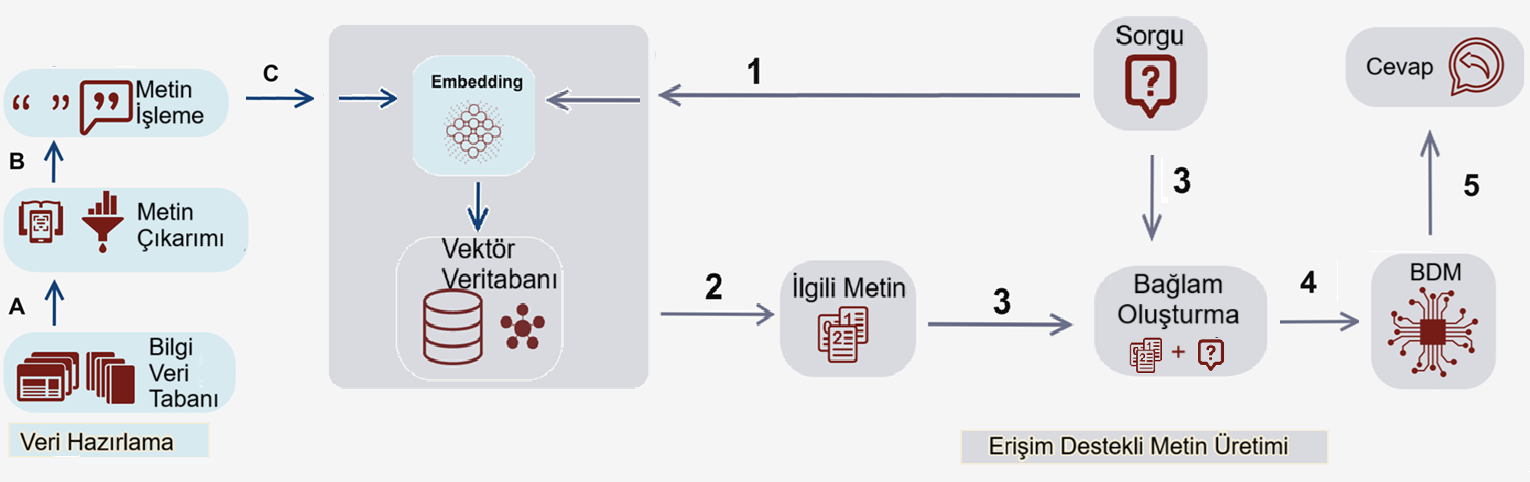

### Neden RAG'a İhtiyaç Duyarız?

### Saf LLM Sistemlerinin Sınırlılıkları:

- 🌐 **Güncel bilgiye erişim eksikliği**: Eğitim verisi güncellense bile yeniden eğitilmesi gerekir. LLM’ler genellikle sabit bilgiye sahiptir.
- 📁 **Harici belgeleri analiz edemezler**: Kullanıcının yüklediği PDF, web sayfası veya dokümanları doğrudan anlamaz.
- ❌ **Kaynak gösteremezler**: Yanıtlar çoğunlukla modelin "tahmini" üzerine kurulduğu için doğrulanabilirlik zayıftır.
- 🧠 **Kısa süreli bağlam hafızası**: Konuşmanın önceki aşamalarını kolayca unutur; uzun belgeleri işlemek zordur.

### RAG ile Bu Sorunlar Nasıl Aşılır?

- ✅ **Harici Bilgiye Erişim**: Belge, web verisi, bilgi tabanı gibi kaynaklara erişerek içerik zenginleştirilir.
- ✅ **Belgeye Dayalı Yanıt**: Kullanıcının yüklediği veya sistemdeki belgeler doğrudan yanıt üretiminde kullanılır.
- ✅ **Özelleştirme İmkanı**: Kurum içi belgelerle alan odaklı chatbot’lar geliştirilebilir (müşteri hizmetleri, iç eğitim, akademik danışman vb.).

## Temel Bileşenleri ve İş Akışı: Veriye Erişim



Erişim Destekli Metin Üretimi (Retrieval-Augmented Generation - RAG) mimarisinin temel iş akışı, sistemin bilgi tabanı oluşturmasından başlayarak kullanıcı sorgusuna yanıt üretimine kadar olan aşamaları kapsar. Bu aşamalar, birbirleriyle uyumlu ve sıralı şekilde çalışarak kullanıcıya yüksek doğrulukta ve güvenilir içerik sağlar.

RAG sisteminin temel dayanağı, dış bilgi kaynaklarının anlamlı ve erişilebilir hale getirilmesidir. Bu amaçla, öncelikle kullanılacak belgeler toplanır, dijital ortamda işlenir ve mantıksal arama (semantic search) için hazır hale getirilir.

- **Belgelerin Toplanması:**
PDF dosyaları, Word belgeleri, web sayfaları, kurumsal dokümanlar veya kullanıcı tarafından yüklenen içerikler bilgi tabanını oluşturur.

- **Belgelerden İçerik Çıkarımı** (Document Processing): Sistem, kullanılacak tüm belgelerden (PDF, web sayfaları, kurumsal dokümanlar vb.) metin çıkarımı (text extraction) yapılır.

- **Parçalama (Chunking)**:
Uzun belgeler, modelin bağlam sınırına uygun olacak şekilde küçük, anlamlı parçalara (chunk) ayrılır.



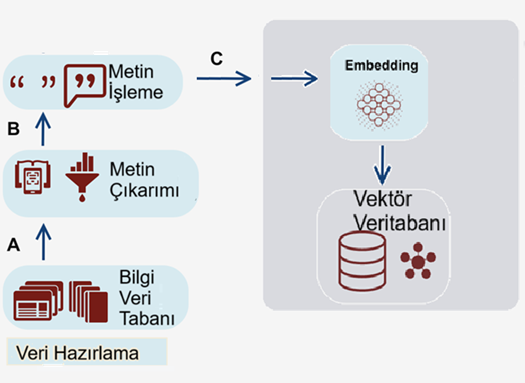

###  Vektör Veritabanı (Vector Database)
Elde edilen metin parçaları vektörlere çevrilir ve vektör veri tabanında saklanır. Bilgi Tabanı (Knowledge Base) oluşturulması ve Vektör Veritabanında (Vector Database) işlenip saklanması süreci, bilgi tabanının sürekli güncellenmesine ve genişletilmesine olanak sağlar. Böylece sistem, statik değil dinamik ve güncel bilgi kaynağı haline gelir.

- **Metinlerin Gömme (Embedding) İşlemi**:
Her metin parçası, anlamsal temsilini yansıtan sayısal vektörlere dönüştürülür. Böylece dil modeli tarafından anlaşılabilir ve karşılaştırılabilir hale gelir.

- **Vektör Veritabanına (Vector Database) Kayıt**:
Elde edilen bu gömme vektörleri, hızlı ve ölçeklenebilir erişim için özel vektör veritabanlarına kaydedilir. Bu veritabanları, anlam benzerliği ölçütlerine göre sorguları işler ve en ilgili içerikleri hızlıca bulur.



## Temel Bileşenleri ve İş Akışı: Metin Üretimi

### Kullanıcı Sorgusu (User Prompt)

Kullanıcı, sistemle doğal dilde etkileşime geçerek bir sorgu iletir. Bu sorgu, klasik anahtar kelime tabanlı arama motorlarından farklı olarak bağlamı anlayan bir sistem içinde işlenir. Kullanıcı sorgusu da bilgi tabanındaki belgeler gibi **gömme (embedding)** işleminden geçirilerek anlamsal vektöre dönüştürülür.

### Anlam Temelli Erişim (Semantic Retrieval)

Kullanıcı sorgusunun vektörü, vektör veritabanındaki tüm belge vektörleriyle karşılaştırılır. Bu karşılaştırma, anlam benzerliği esasına dayanır ve sorguya en yakın, en alakalı belge parçaları seçilir. Bu aşamada:

- Vektör veritabanı, yüksek boyutlu uzayda hızlı ve etkili benzerlik araması yapar.

- Geleneksel kelime eşleşmesinden ziyade, kavramsal ve bağlamsal benzerlikler üzerinden erişim sağlanır.




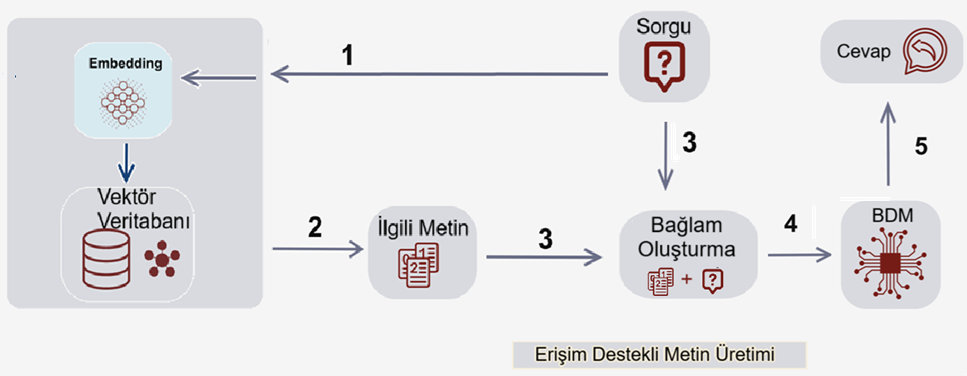

### Bağlam Oluşturma (Contextual Fusion)

Erişim aşamasında seçilen belge parçaları, kullanıcı sorgusu ile birlikte birleştirilerek büyük dil modeline (LLM) gönderilecek kapsamlı ve zengin bir bağlam oluşturulur. Bu bağlam, modelin doğru, tutarlı ve kaynak bazlı yanıtlar üretebilmesi için kritik öneme sahiptir.

- Örnek yapı:  Kullanıcı Yönlendirmesi (User Prompt) + Belge1 + Belge2 + Belge3

- Bağlam uzunluğu, modelin bağlam penceresi (context window) göz önünde bulundurularak optimize edilir.

### Metin (Yanıt) Üretimi (Generation)

Son adımda, oluşturulan bağlam büyük dil modeline (LLM) gönderilir ve model bu bilgileri işleyerek kullanıcıya bir yanıt üretir.

📌 **Yanıtın Özellikleri:**

- Erişimle getirilen belge içeriklerine dayalı, doğrulanabilir ve güncel bilgi sunar.

- Gerekirse kaynakça veya referans linkleri sağlar.

- Halüsinasyon (uydurma bilgi) üretme riski oldukça düşüktür.

- Kullanıcının sorgusuna uygun, bağlama duyarlı ve görev odaklı yanıtlar üretir.


## Faydaları ve Kısıtları

### Faydaları

| 🚀 Özellik              | 🎯 Açıklama                                                                                     |
|------------------------|------------------------------------------------------------------------------------------------|
| 🔍 Güncel Bilgi Erişimi | Veritabanı güncellenerek sistemin yanıtları değiştirilebilir. Model yeniden eğitilmez.          |
| 🧾 Belge Tabanlı Yanıt  | Belgeye doğrudan yanıt verilebilir. Örneğin, “Bu sözleşmeye göre ceza maddesi nedir?”           |
| 📌 Alan Uzmanlığı       | Sistem sadece belirli belge setleriyle çalıştığı için hedef odaklı ve tutarlı yanıtlar üretir.   |
| 🎯 Halüsinasyon Azalır  | Modelin yanıtları gerçek belgelere dayandığı için uydurma içerik üretme riski azalır.           |


### Kısıtlar ve Zorluklar

| ❌ Sınırlılık           | 🧠 Açıklama                                                        |
|------------------------|------------------------------------------------------------------|
| 📐 Gömme Kalitesi       | Kalitesiz embedding modelleri, alakasız belgeleri getirebilir.   |
| 🗂️ Veri Temizliği       | Gürültülü, formatı bozuk veya tutarsız belgeler hatalı erişim sonuçlarına yol açabilir. |
| 🧩 Bağlam Penceresi     | Uzun belgeler bağlam sınırını aşabilir, bu da kesme, özetleme ya da seçim gerektirir. |
| ⏱️ Gecikme (Latency)    | Erişim + üretim işlemi, saf LLM kullanıma göre daha fazla zaman alabilir. |
| 🔒 Gizlilik ve Güvenlik | Kurumsal sistemlerde verilerin güvenliği, erişim kontrolü ve şifreleme büyük önem taşır. |

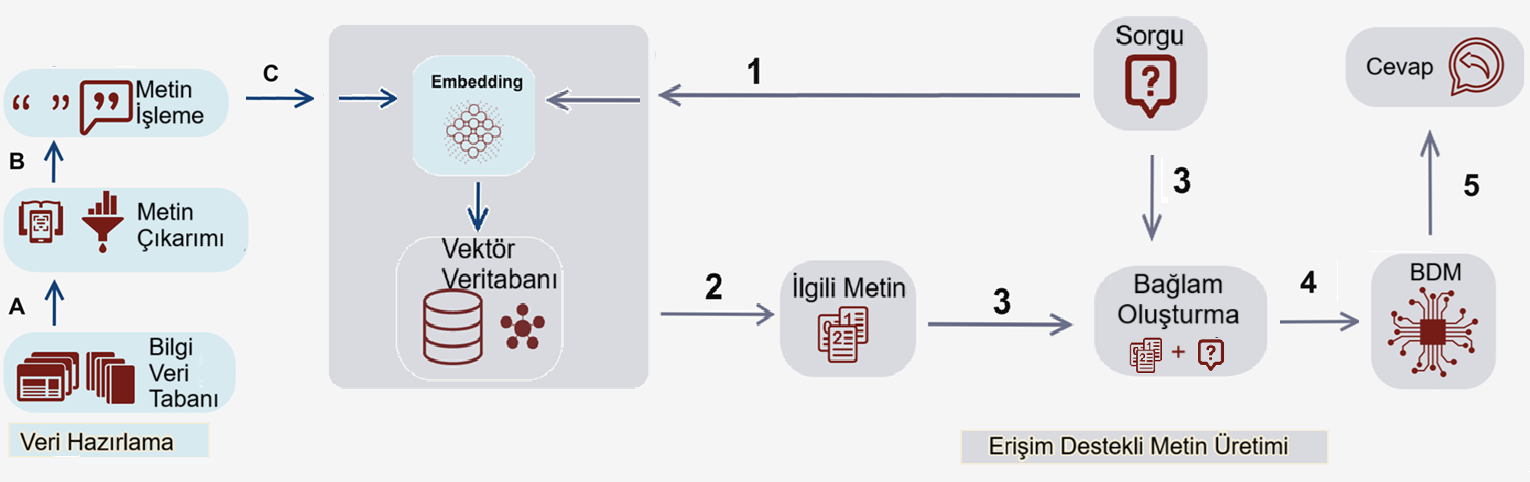

### Bu Bölümden Sonra Neler Öğreneceğiz?

Bu bölümde, RAG mimarisinin nasıl çalıştığını teorik ve pratik yönleriyle öğrendik. Artık temel parçaların ne olduğunu, nasıl etkileştiğini ve neden bu yaklaşımın LLM sistemlerini geliştirdiğini biliyoruz.

📌 Sonraki bölümde:

- Vektör veritabanı olarak **ChromaDB** nasıl kurulur ve kullanılır?
- Belgeler nasıl gömülür (embed edilir) ve veritabanına aktarılır?
- Arama ve erişim işlemleri nasıl yapılır?

💡 Bunları öğrendikten sonra, LLM + ChromaDB ile tam işleyen bir erişim destekli sohbet botu sistemini uçtan uca kuracak seviyeye geleceğiz.

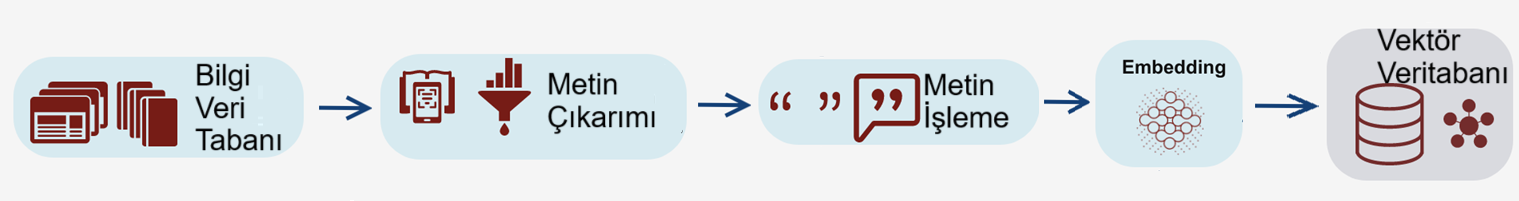